# Pantanal BirdCLEF 2026 — Data Processing & Two-Phase Training

**Phase 1**: Pre-train on short bird clips (XC / iNat) — head only, backbone frozen  
**Phase 2**: Fine-tune on labeled soundscape segments — full model, lower LR

In [2]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

SEED = 42

bird_audio_dir = "/home/users/ss1482/sangcs372final/Finalproject/birdtrain_wav"
soundscape_dir = "/home/users/ss1482/sangcs372final/Finalproject/soundtrain"

# =========================
# 1. LOAD TRAIN AUDIO METADATA
# =========================
df = pd.read_csv("train.csv")

# Strip the subdirectory prefix, then convert extension
df["filename"] = df["filename"].apply(lambda x: os.path.basename(x))  # '1161364/iNat1216197.ogg' → 'iNat1216197.ogg'
df["filename"] = df["filename"].str.replace(".ogg", ".wav", regex=False)

df["filepath"] = df["filename"].apply(lambda x: os.path.join(bird_audio_dir, x))
df = df[df["filepath"].apply(os.path.exists)].reset_index(drop=True)
print("Files found:", len(df))
# =========================
# 2. LOAD SOUNDSCAPE LABELS
# =========================
ss_df = pd.read_csv("train_soundscapes_labels.csv")

# Convert filenames
ss_df["filename"] = ss_df["filename"].str.replace(".ogg", ".wav", regex=False)

# Path to soundscape wavs
soundscape_dir = "/home/users/ss1482/sangcs372final/Finalproject/soundtrain"

# Build filepaths
ss_df["filepath"] = ss_df["filename"].apply(lambda x: os.path.join(soundscape_dir, x))

# Remove missing files
ss_df = ss_df[ss_df["filepath"].apply(os.path.exists)].reset_index(drop=True)

print("Soundscape segments:", len(ss_df))


# =========================
# 3. LOAD TAXONOMY
# =========================
taxonomy = pd.read_csv("taxonomy.csv")
labels = taxonomy["primary_label"].values
label_to_idx = {label: i for i, label in enumerate(labels)}
idx_to_label = {i: label for label, i in label_to_idx.items()}
NUM_CLASSES = len(labels)
print("Total classes:", NUM_CLASSES)


# =========================
# 4. SPLIT BIRD CLIPS  (stratified by species)
# =========================
# Species with only 1 sample can't be stratified — pull them out first
counts = df["primary_label"].value_counts()
rare   = set(counts[counts < 2].index)

df_rare     = df[df["primary_label"].isin(rare)]
df_stratify = df[~df["primary_label"].isin(rare)]

bird_train_df, bird_val_df = train_test_split(
    df_stratify,
    test_size=0.2,
    stratify=df_stratify["primary_label"],
    random_state=SEED
)

# Rare species go entirely to train (can't validate what you barely have)
bird_train_df = pd.concat([bird_train_df, df_rare]).reset_index(drop=True)
bird_val_df   = bird_val_df.reset_index(drop=True)

print(f"\nBird clips  → train: {len(bird_train_df)}  val: {len(bird_val_df)}")


# =========================
# 5. SPLIT SOUNDSCAPES  (split by FILE, not by segment — avoids leakage)
# =========================
# Adjacent 5-second segments from the same file are highly correlated,
# so we group all segments from a file together before splitting.
unique_files = ss_df["filename"].unique()

ss_train_files, ss_val_files = train_test_split(
    unique_files,
    test_size=0.2,
    random_state=SEED
)

ss_train_df = ss_df[ss_df["filename"].isin(ss_train_files)].reset_index(drop=True)
ss_val_df   = ss_df[ss_df["filename"].isin(ss_val_files)].reset_index(drop=True)

print(f"Soundscapes → train files: {len(ss_train_files)}  val files: {len(ss_val_files)}")
print(f"             train segs:  {len(ss_train_df)}  val segs:  {len(ss_val_df)}")

print("\nUnique train_audio species:", df["primary_label"].nunique())
print("Species missing from train_audio:", NUM_CLASSES - df["primary_label"].nunique())

Files found: 12729
Soundscape segments: 1478
Total classes: 234

Bird clips  → train: 10183  val: 2546
Soundscapes → train files: 52  val files: 14
             train segs:  1160  val segs:  318

Unique train_audio species: 80
Species missing from train_audio: 154


In [3]:
def time_to_seconds(t):
    if isinstance(t, (int, float)):
        return float(t)
    if isinstance(t, str):
        h, m, s = t.split(":")
        return int(h) * 3600 + int(m) * 60 + float(s)
    raise ValueError(f"Invalid time format: {t}")

In [4]:
import numpy as np
import soundfile as sf
import librosa

TARGET_SR = 32000

def load_audio_segment(filepath, target_len, start_sec=None):
    try:
        audio, sr = sf.read(filepath)
    except:
        return np.zeros(target_len, dtype=np.float32)

    if audio.ndim == 2:
        audio = np.mean(audio, axis=1)

    if sr != TARGET_SR:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=TARGET_SR)

    audio = audio.astype(np.float32)

    if start_sec is not None:
        start_sec = time_to_seconds(start_sec)
        start = int(start_sec * TARGET_SR)
        end   = start + target_len
        audio = audio[start:end]

    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]

    # ── Normalize so the backbone gets consistent input energy ──
    max_val = np.abs(audio).max()
    if max_val > 0:
        audio = audio / max_val          # peak normalize to [-1, 1]

    return audio


In [5]:
import torch
from torch.utils.data import Dataset

class BaseAudioDataset(Dataset):
    def __init__(self, df, label_to_idx, clip_duration, multi_label=False, augment=False):
        self.df           = df.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.clip_len     = TARGET_SR * clip_duration
        self.multi_label  = multi_label
        self.augment      = augment

    def __len__(self):
        return len(self.df)

    def get_audio(self, row):
        return load_audio_segment(row["filepath"], self.clip_len)

    def get_label(self, row):
        label = torch.zeros(len(self.label_to_idx))
        if self.multi_label:
            for sp in str(row["primary_label"]).split(";"):
                if sp in self.label_to_idx:
                    label[self.label_to_idx[sp]] = 1.0
        else:
            if row["primary_label"] in self.label_to_idx:
                label[self.label_to_idx[row["primary_label"]]] = 1.0
        return label

    def _maybe_augment(self, audio):
        """Light waveform augmentation — only applied during training."""
        if not self.augment:
            return audio
        # Random gain
        gain  = np.random.uniform(0.6, 1.4)
        audio = audio * gain
        # Gaussian noise
        if np.random.rand() < 0.5:
            noise = np.random.randn(len(audio)).astype(np.float32)
            audio = audio + noise * np.random.uniform(0.001, 0.01)
        return np.clip(audio, -1.0, 1.0)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        audio = self.get_audio(row)
        audio = self._maybe_augment(audio)
        audio = torch.tensor(audio) 
        label = self.get_label(row)
        return audio, label

In [6]:
class BirdDataset(BaseAudioDataset):
    """Short XC/iNat clips — single primary label, 10-second clips."""
    def __init__(self, df, label_to_idx, augment=False):
        super().__init__(df, label_to_idx, clip_duration=10,
                         multi_label=False, augment=augment)

In [7]:
class SoundscapeDataset(BaseAudioDataset):
    """Labeled soundscape segments — multi-label, 5-second clips."""
    def __init__(self, df, label_to_idx, augment=False):
        super().__init__(df, label_to_idx, clip_duration=5,
                         multi_label=True, augment=augment)

    def get_audio(self, row):
        return load_audio_segment(
            row["filepath"],
            self.clip_len,
            start_sec=row["start"]
        )

In [8]:
from torch.utils.data import DataLoader
batch_size = 16
batch_size = 16
# ── Bird clip datasets (augment train only) ──────────────────
bird_train_ds = BirdDataset(bird_train_df, label_to_idx, augment=True)
bird_val_ds   = BirdDataset(bird_val_df,   label_to_idx, augment=False)

bird_train_loader = DataLoader(bird_train_ds, batch_size=batch_size, shuffle=True,
                               num_workers=1, pin_memory=batch_size, drop_last=True)
bird_val_loader   = DataLoader(bird_val_ds,   batch_size=16, shuffle=False,
                               num_workers=1, pin_memory=True)

# ── Soundscape datasets ──────────────────────────────────────
ss_train_ds = SoundscapeDataset(ss_train_df, label_to_idx, augment=True)
ss_val_ds   = SoundscapeDataset(ss_val_df,   label_to_idx, augment=False)

ss_train_loader = DataLoader(ss_train_ds, batch_size=16, shuffle=True,
                             num_workers=1, pin_memory=True, drop_last=True)
ss_val_loader   = DataLoader(ss_val_ds,   batch_size=16, shuffle=False,
                             num_workers=1, pin_memory=True)

print(f"Bird    — train batches: {len(bird_train_loader)}  val batches: {len(bird_val_loader)}")
print(f"Soundsc — train batches: {len(ss_train_loader)}  val batches: {len(ss_val_loader)}")

Bird    — train batches: 636  val batches: 160
Soundsc — train batches: 72  val batches: 20


In [9]:
import sys
sys.path.append("/home/users/ss1482/sangcs372final/audioset_tagging_cnn")
sys.path.append("/home/users/ss1482/sangcs372final/audioset_tagging_cnn/pytorch")

from pytorch.models import Cnn14

In [10]:
model = Cnn14(
    sample_rate=32000,
    window_size=1024,
    hop_size=320,
    mel_bins=64,
    fmin=50,
    fmax=14000,
    classes_num=527   # original AudioSet head — will be replaced below
)

In [11]:
checkpoint = torch.load("Cnn14_mAP=0.431.pth", map_location="cpu")
model.load_state_dict(checkpoint["model"], strict=False)
print("Pretrained weights loaded.")

Pretrained weights loaded.


In [12]:
# Replace AudioSet head (527 classes) with our Pantanal head (234 classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.fc_audioset = torch.nn.Sequential(
    torch.nn.Linear(2048, 512),
    torch.nn.BatchNorm1d(512),   # normalizes the sparse fc1 output
    torch.nn.GELU(),             # GELU doesn't hard-zero negatives like ReLU does
    torch.nn.Dropout(0.3),
    torch.nn.Linear(512, NUM_CLASSES)
).to(device)


model  = model.to(device)
print("Model ready on:", device)

Model ready on: cuda


In [13]:
def freeze_backbone_partial(model):
    for name, param in model.named_parameters():
        param.requires_grad = False

    for name, param in model.named_parameters():
        if any(x in name for x in ["conv_block4", "conv_block5", "conv_block6", "fc1", "fc_audioset"]):
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Partial freeze. Trainable params: {trainable:,}")
def unfreeze_all(model):
    """Unfreeze every layer for full fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True
    total = sum(p.numel() for p in model.parameters())
    print(f"All layers unfrozen. Total trainable params: {total:,}")

In [14]:
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

def run_validation(model, loader, criterion, device):
    """Returns average val loss, macro ROC-AUC, and per-class AUC dictionary."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for audio, label in loader:
            audio, label = audio.to(device), label.to(device)
            output = model(audio)
            logits = output["clipwise_output"] if isinstance(output, dict) else output
            loss = criterion(logits, label)
            total_loss += loss.item()
            
            all_preds.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(label.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # 1. Calculate Per-Class AUC
    per_class_auc = {}
    n_classes = all_labels.shape[1]
    
    for i in range(n_classes):
        # We can only calculate AUC if the class has both positive and negative samples in the val set
        if len(np.unique(all_labels[:, i])) > 1:
            score = roc_auc_score(all_labels[:, i], all_preds[:, i])
            per_class_auc[i] = score
        else:
            per_class_auc[i] = np.nan # Not enough data in this split for this bird

    # 2. Calculate Macro AUC (ignoring NaNs)
    valid_scores = [v for v in per_class_auc.values() if not np.isnan(v)]
    macro_auc = np.mean(valid_scores) if valid_scores else 0.0

    return total_loss / len(loader), macro_auc, per_class_auc

## Phase 1 — Pre-train on Bird Clips (backbone frozen)

Only the new 234-class head is trained here.  
The CNN14 backbone keeps its AudioSet weights and learns nothing yet — this prevents catastrophic forgetting while the head finds reasonable initialisation.

In [15]:
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class Cnn14Pantanal(nn.Module):
    def __init__(self, base_model, num_classes):
        super().__init__()
        # Copy all layers from the pretrained model
        self.spectrogram_extractor = base_model.spectrogram_extractor
        self.logmel_extractor      = base_model.logmel_extractor
        self.spec_augmenter        = base_model.spec_augmenter
        self.bn0         = base_model.bn0
        self.conv_block1 = base_model.conv_block1
        self.conv_block2 = base_model.conv_block2
        self.conv_block3 = base_model.conv_block3
        self.conv_block4 = base_model.conv_block4
        self.conv_block5 = base_model.conv_block5
        self.conv_block6 = base_model.conv_block6
        
        # FIX: Wrap fc1 in Sequential to match the saved state_dict "fc1.0.weight"
        self.fc1 = nn.Sequential(
            base_model.fc1  # This keeps the pretrained weights as the 0th element
        )
        
        self.gelu = nn.GELU() 

        # New head for 234 classes
        self.fc_audioset = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, input):
        x = self.spectrogram_extractor(input)
        x = self.logmel_extractor(x)

        x = x.transpose(1, 3)
        x = self.bn0(x)
        x = x.transpose(1, 3)

        if self.training:
            x = self.spec_augmenter(x)

        x = self.conv_block1(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv_block2(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv_block3(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv_block4(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv_block5(x, pool_size=(2, 2), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv_block6(x, pool_size=(1, 1), pool_type='avg')
        x = F.dropout(x, p=0.2, training=self.training)

        x = torch.mean(x, dim=3)
        (x1, _) = torch.max(x, dim=2)
        x2 = torch.mean(x, dim=2)
        x = x1 + x2

        x = F.dropout(x, p=0.5, training=self.training)
        
        # Because fc1 is now Sequential, we call it directly. 
        # The weight is now internally stored at self.fc1[0].weight
        x = self.gelu(self.fc1(x)) 
        
        x = F.dropout(x, p=0.5, training=self.training)
        logits = self.fc_audioset(x)

        return {"clipwise_output": logits, "embedding": x}
# ── Wrap the existing model ──────────────────────────────────
model = Cnn14Pantanal(model, NUM_CLASSES).to(device)

# ── Verify fc1 zeros are gone ────────────────────────────────
activations = {}
def hook_fn(module, input, output):
    activations["fc1"] = output.detach()

hook = model.fc1.register_forward_hook(hook_fn)
audio, label = next(iter(bird_train_loader))
with torch.no_grad():
    model(audio.to(device))
hook.remove()

print("fc1 output mean:", activations["fc1"].mean().item())
print("fc1 output std: ", activations["fc1"].std().item())
print("fc1 zeros:      ", (activations["fc1"] == 0).float().mean().item())

fc1 output mean: -0.29005950689315796
fc1 output std:  0.5920659899711609
fc1 zeros:       0.0


In [16]:
import os
import torch.optim as optim

# ── Hyperparameters ──────────────────────────────────────────
PHASE1_EPOCHS  = 10
WEIGHT_DECAY   = 1e-2
BATCH_SIZE     = 8
WARMUP_EPOCHS  = 0
PATIENCE       = 3
MIN_DELTA      = 1e-4
RESUME         = True   # ← NEW

# ── Early stopping state ─────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=PATIENCE, min_delta=MIN_DELTA):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_auc   = 0.0
        self.should_stop = False

    def step(self, val_auc):
        if val_auc > self.best_auc + self.min_delta:
            self.best_auc  = val_auc
            self.counter   = 0
        else:
            self.counter  += 1
            print(f"  ↳ No improvement for {self.counter}/{self.patience} epochs")
            if self.counter >= self.patience:
                self.should_stop = True
                print("  ✗ Early stopping triggered.")

# Freeze backbone
freeze_backbone_partial(model)

criterion = torch.nn.BCEWithLogitsLoss()

optimizer = optim.AdamW([
    {"params": [p for n,p in model.named_parameters() if "conv_block4" in n], "lr": 1e-5},
    {"params": [p for n,p in model.named_parameters() if "conv_block5" in n], "lr": 5e-5},
    {"params": [p for n,p in model.named_parameters() if "conv_block6" in n], "lr": 1e-4},
    {"params": [p for n,p in model.named_parameters() if "fc1" in n],         "lr": 2e-4},
    {"params": [p for n,p in model.named_parameters() if "fc_audioset" in n], "lr": 5e-4},
], weight_decay=WEIGHT_DECAY)

def get_lr_scale(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / max(1, WARMUP_EPOCHS)
    progress = (epoch - WARMUP_EPOCHS) / max(1, PHASE1_EPOCHS - WARMUP_EPOCHS)
    return 0.1 + 0.9 * 0.5 * (1 + torch.cos(torch.tensor(3.14159 * progress)).item())

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_scale)

early_stopper = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA)

Partial freeze. Trainable params: 79,698,666


In [17]:
# Run ONE forward+backward pass and check if gradients are actually flowing
model.train()
audio, label = next(iter(bird_train_loader))
audio = audio.to(device)
label = label.to(device)

optimizer.zero_grad()
output = model(audio)
logits = output["clipwise_output"] if isinstance(output, dict) else output
loss   = criterion(logits, label)
loss.backward()

# Check gradient magnitudes on the head and a mid-level layer
for name, param in model.named_parameters():
    if param.grad is not None and param.grad.abs().max() > 0:
        print(f"{name:50s}  grad_max={param.grad.abs().max():.6f}")

conv_block4.conv1.weight                            grad_max=0.000088
conv_block4.conv2.weight                            grad_max=0.000040
conv_block4.bn1.weight                              grad_max=0.000428
conv_block4.bn1.bias                                grad_max=0.000288
conv_block4.bn2.weight                              grad_max=0.000621
conv_block4.bn2.bias                                grad_max=0.000401
conv_block5.conv1.weight                            grad_max=0.000070
conv_block5.conv2.weight                            grad_max=0.000044
conv_block5.bn1.weight                              grad_max=0.000617
conv_block5.bn1.bias                                grad_max=0.000343
conv_block5.bn2.weight                              grad_max=0.000437
conv_block5.bn2.bias                                grad_max=0.000278
conv_block6.conv1.weight                            grad_max=0.000046
conv_block6.conv2.weight                            grad_max=0.000043
conv_block6.bn1.weig

In [18]:


# ── Resume logic ─────────────────────────────────────────────
start_epoch = 1
best_phase1_auc = 0.0

if RESUME and os.path.exists("bestbest_phase1.pth"):
    ckpt = torch.load("bestbest_phase1.pth", map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])

    if "scheduler" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler"])

    start_epoch = ckpt["epoch"] + 1
    best_phase1_auc = ckpt["val_auc"]

    print(f"Resuming from epoch {start_epoch-1}, best AUC {best_phase1_auc:.4f}")

# ── Training loop ────────────────────────────────────────────
for epoch in range(start_epoch, PHASE1_EPOCHS + 1):

    model.train()
    running_loss = 0.0

    for batch_idx, (audio, label) in enumerate(bird_train_loader):
        audio = audio.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        output = model(audio)
        logits = output["clipwise_output"] if isinstance(output, dict) else output
        loss   = criterion(logits, label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        if (batch_idx + 1) % 50 == 0:
            current_lr = optimizer.param_groups[0]["lr"]
            print(f"  [P1 E{epoch} step {batch_idx+1}] "
                  f"loss: {running_loss/(batch_idx+1):.4f}  lr: {current_lr:.2e}")

    scheduler.step()

    # ── validate ─────────────────────────────────────────────
    val_loss, val_auc = run_validation(model, bird_val_loader, criterion, device)
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch}/{PHASE1_EPOCHS}  "
          f"train_loss={running_loss/len(bird_train_loader):.4f}  "
          f"val_loss={val_loss:.4f}  val_auc={val_auc:.4f}  "
          f"lr={current_lr:.2e}")

    # ── save latest (NEW, optional but useful) ────────────────
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "val_auc": val_auc,
        "batch_size": BATCH_SIZE,
    }, "latest_phase1.pth")

    # ── checkpoint if best ───────────────────────────────────
    if val_auc > best_phase1_auc:
        best_phase1_auc = val_auc
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),  # ← added
            "val_auc": val_auc,
            "batch_size": BATCH_SIZE,
        }, "bestbest_phase1.pth")
        print("  ✓ Saved best Phase 1 checkpoint")

    # ── early stopping ───────────────────────────────────────
    early_stopper.step(val_auc)
    if early_stopper.should_stop:
        print(f"\nStopped early at epoch {epoch}. "
              f"Best val AUC: {best_phase1_auc:.4f}")
        break

else:
    print(f"\nPhase 1 complete. Best val AUC: {best_phase1_auc:.4f}")

# ── safe reload ──────────────────────────────────────────────
if os.path.exists("bestbest_phase1.pth"):
    print("Reloading best Phase 1 weights...")
    model.load_state_dict(torch.load("best_phase1.pth")["model"])
else:
    print("No checkpoint found to reload.")


Resuming from epoch 10, best AUC 0.9817

Phase 1 complete. Best val AUC: 0.9817
Reloading best Phase 1 weights...


## Phase 2 — Fine-tune on Labeled Soundscapes (all layers unfrozen)

Now we unfreeze the backbone and train on the real field recordings.  
We use **discriminative learning rates**: the backbone gets a much lower LR than the head to avoid destroying what it learned in Phase 1.

In [20]:
def mixup_data(x, y, alpha=0.2):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    mixed_y = lam * y + (1 - lam) * y[index, :]
    return mixed_x, mixed_y

In [30]:
def train_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=30,
    lr=1e-4,
    patience=5,
    mixup_fn=None,
    val_fn=None,
    accum_steps=4,
    save_path="best_model.pth",
    idx_to_label=None,   # 👈 bird names live here now
):
    model = model.to(device)

    early_stopper = EarlyStopping(patience=patience, mode='max')
    criterion = FocalLoss(gamma=2.0)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    train_losses, val_losses, val_aucs = [], [], []

    print("Starting training...")

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        optimizer.zero_grad()

        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)

            if mixup_fn is not None:
                x, y = mixup_fn(x, y)

            output = model(x)

            # 👇 Handle different model outputs
            if isinstance(output, dict):
                logits = output.get("clipwise_output", list(output.values())[0])
            else:
                logits = output

            loss = criterion(logits, y)
            (loss / accum_steps).backward()

            if (i + 1) % accum_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                optimizer.zero_grad()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        # 👇 validation function must return (loss, auc, per_class_dict)
        val_loss, val_auc, per_class_auc = val_fn(model, val_loader, criterion, device)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        val_aucs.append(val_auc)

        scheduler.step(val_auc)
        early_stopper(val_auc)

        print(f"Epoch {epoch} | Loss: {avg_train_loss:.4f} | Val AUC: {val_auc:.4f}")

        # 🐦 Per-class reporting (only if labels provided)
        if idx_to_label is not None and per_class_auc is not None:
            valid_scores = [
                (idx, score) for idx, score in per_class_auc.items()
                if not np.isnan(score)
            ]

            if valid_scores:
                sorted_auc = sorted(valid_scores, key=lambda x: x[1], reverse=True)

                top3 = [(idx_to_label[i], f"{s:.3f}") for i, s in sorted_auc[:3]]
                bot3 = [(idx_to_label[i], f"{s:.3f}") for i, s in sorted_auc[-3:]]

                print(f"  > Top 3 Birds: {top3}")
                print(f"  > Bottom 3 Birds: {bot3}")

        # 💾 Save best model + CSV
        if val_auc == max(val_aucs):
            torch.save({"model": model.state_dict(), "auc": val_auc}, save_path)

            if idx_to_label is not None and per_class_auc is not None:
                results_data = [
                    {"Bird_Name": idx_to_label[idx], "AUC": score}
                    for idx, score in per_class_auc.items()
                ]
                pd.DataFrame(results_data).to_csv(
                    "best_per_class_auc.csv", index=False
                )

            print("  ✓ Saved best model")

        if early_stopper.early_stop:
            print(f"Early stopping at epoch {epoch}")
            break

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_aucs": val_aucs,
    }

In [ ]:
results = train_model(
    model=model,
    train_loader=ss_train_loader,
    val_loader=ss_val_loader,
    device=device,
    epochs=PHASE2_EPOCHS,
    lr=1e-4,  
    patience=PATIENCE,
    mixup_fn=lambda x, y: mixup_data(x, y, alpha=MIXUP_ALPHA),
    val_fn=run_validation,
    accum_steps=ACCUM_STEPS,
    save_path="best_phase2.pth",
    idx_to_label=idx_to_label,  
)

Starting training...
Epoch 1 | Loss: 0.0448 | Val AUC: 0.6680
  > Top 3 Birds: [('23158', '0.993'), ('litnig1', '0.950'), ('24321', '0.940')]
  > Bottom 3 Birds: [('22961', '0.351'), ('rutjac1', '0.329'), ('1491113', '0.220')]
  ✓ Saved best model
Improvement detected! Counter reset.
Epoch 2 | Loss: 0.0407 | Val AUC: 0.6741
  > Top 3 Birds: [('23158', '0.998'), ('24321', '0.952'), ('litnig1', '0.947')]
  > Bottom 3 Birds: [('22961', '0.378'), ('rutjac1', '0.297'), ('1491113', '0.236')]
  ✓ Saved best model
Improvement detected! Counter reset.
Epoch 3 | Loss: 0.0320 | Val AUC: 0.6865
  > Top 3 Birds: [('23158', '0.998'), ('litnig1', '0.975'), ('24321', '0.960')]
  > Bottom 3 Birds: [('undtin1', '0.344'), ('rutjac1', '0.272'), ('1491113', '0.245')]
  ✓ Saved best model
Improvement detected! Counter reset.
Epoch 4 | Loss: 0.0303 | Val AUC: 0.6902
  > Top 3 Birds: [('23158', '0.995'), ('24321', '0.969'), ('litnig1', '0.958')]
  > Bottom 3 Birds: [('1491113', '0.283'), ('rutjac1', '0.278'),

In [ ]:
train_losses = results["train_losses"]
val_losses   = results["val_losses"]
val_aucs     = results["val_aucs"]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Loss Curves (Focal Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_aucs, color='green', label='Val AUC')
plt.title('AUC History')

plt.show()

Loaded best Phase 2 checkpoint (val AUC: 0.6891839257777189)

Total species: 234
  Evaluable (appeared in val set): 40 (17.1%)
  Not evaluable (NaN — no val examples): 194 (82.9%)

Among evaluable species:
  Mean AUC:   0.689
  Median AUC: 0.704
  AUC > 0.8:  12 species
  AUC 0.5–0.8:24 species
  AUC < 0.5:  4 species (worse than random)


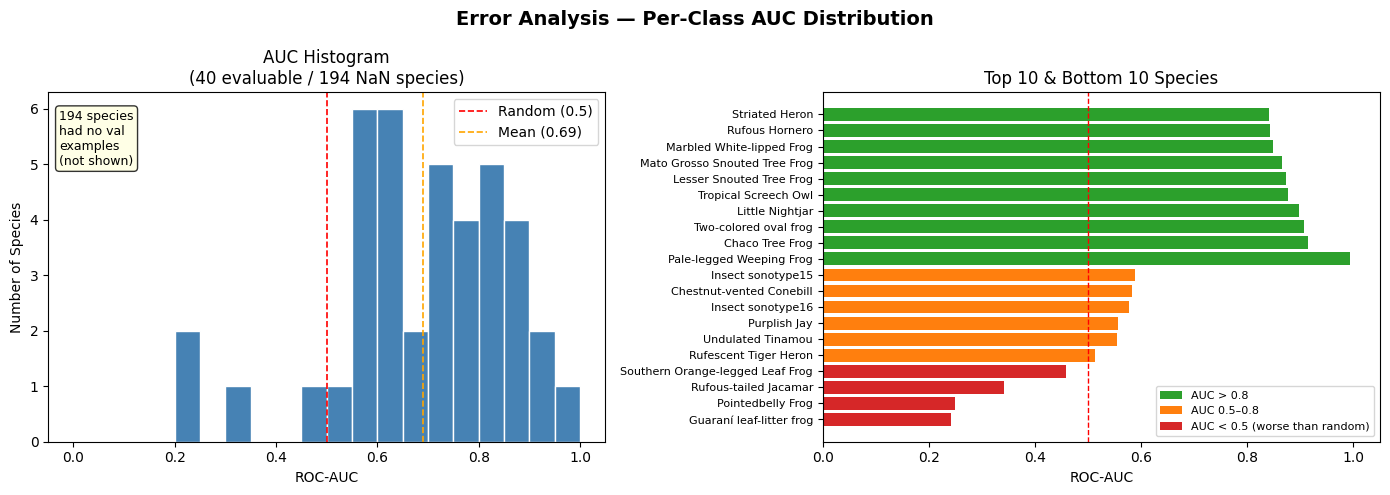

Saved: error_analysis_fig1_auc_distribution.png


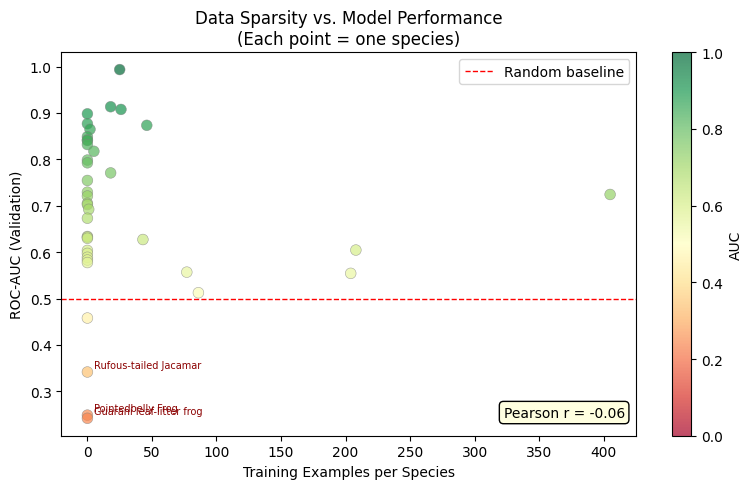

Saved: error_analysis_fig2_sparsity.png  |  Pearson r = -0.06


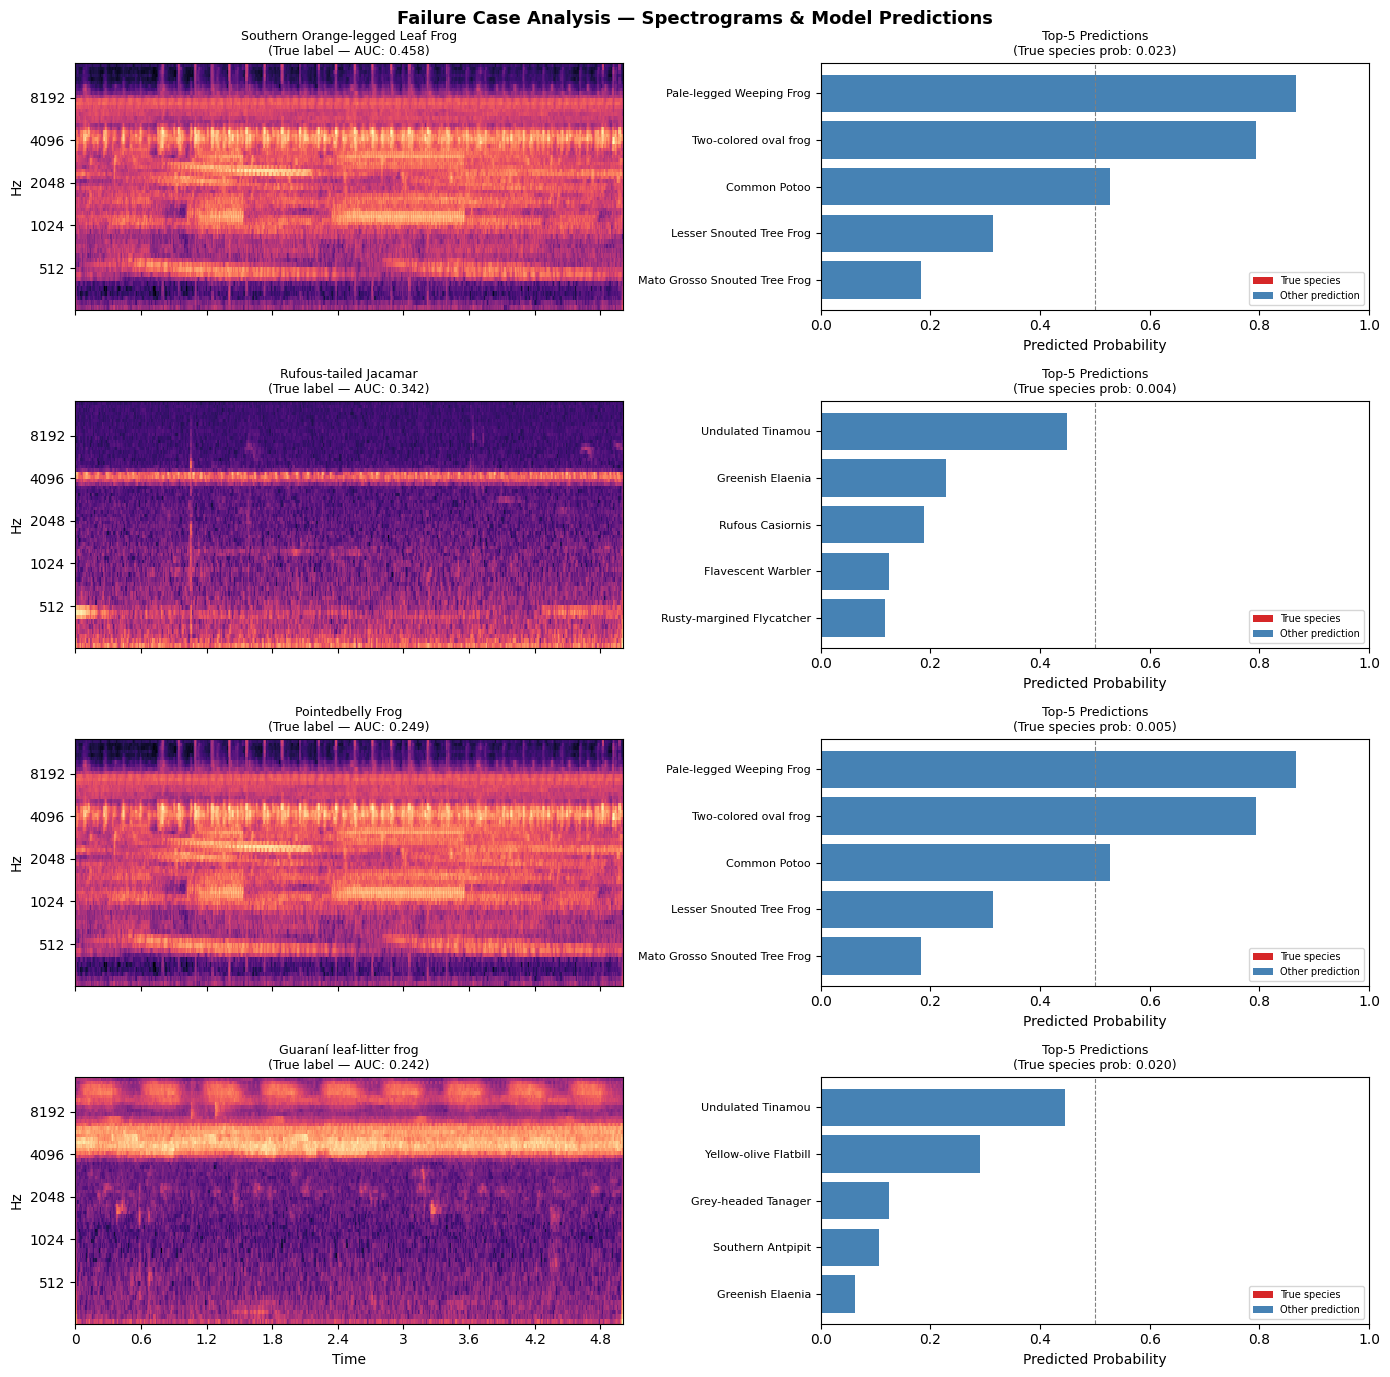

Saved: error_analysis_fig3_failure_cases.png

════════════════════════════════════════════════════════════
ERROR ANALYSIS SUMMARY
════════════════════════════════════════════════════════════

1. COVERAGE: Only 40/234 species (17%) could be
   evaluated. 194 species had zero validation examples due to
   extreme class imbalance — a fundamental data sparsity problem.

2. PERFORMANCE DISTRIBUTION (among evaluable species):
   High (AUC > 0.8):       12 species
   Mediocre (0.5–0.8):     24 species
   Worse than random (<0.5): 4 species

3. SPARSITY CORRELATION: Pearson r = -0.06 between training
   sample count and AUC — more data = better performance.

4. WORST SPECIES:
   Guaraní leaf-litter frog        AUC=0.242  train_n=0
   Pointedbelly Frog               AUC=0.249  train_n=0
   Rufous-tailed Jacamar           AUC=0.342  train_n=0
   Southern Orange-legged Leaf Frog  AUC=0.458  train_n=0
   Rufescent Tiger Heron           AUC=0.513  train_n=86

5. BEST SPECIES:
   Pale-legged Weeping

In [24]:
# ══════════════════════════════════════════════════════════════════
# ERROR ANALYSIS — Pantanal BirdCLEF 2026
# ══════════════════════════════════════════════════════════════════
# Assumes the following already exist from earlier cells:
#   - All class/dataset definitions (BaseAudioDataset, SoundscapeDataset, etc.)
#   - ss_val_df, label_to_idx, idx_to_label, NUM_CLASSES, TARGET_SR
#   - taxonomy loaded as pd.read_csv("taxonomy.csv")
#   - best_per_class_auc.csv saved from Phase 2 training
# ══════════════════════════════════════════════════════════════════

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

# ── 0. Reconstruct model and load best checkpoint ─────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import sys
sys.path.append("/home/users/ss1482/sangcs372final/audioset_tagging_cnn")
sys.path.append("/home/users/ss1482/sangcs372final/audioset_tagging_cnn/pytorch")
from pytorch.models import Cnn14

base_model = Cnn14(
    sample_rate=32000, window_size=1024, hop_size=320,
    mel_bins=64, fmin=50, fmax=14000, classes_num=527
)

model = Cnn14Pantanal(base_model, NUM_CLASSES).to(device)

ckpt = torch.load("best_phase2.pth", map_location=device, weights_only=False)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Loaded best Phase 2 checkpoint (val AUC: {ckpt.get('auc', 'N/A')})")

# ── 1. Load AUC results + enrich with common names ────────────────
auc_df = pd.read_csv("best_per_class_auc.csv")
auc_df.columns = ["primary_label", "AUC"]

taxonomy = pd.read_csv("taxonomy.csv")

# Use common_name if available, otherwise fall back to primary_label
if "common_name" in taxonomy.columns:
    auc_df = auc_df.merge(taxonomy[["primary_label", "common_name"]], on="primary_label", how="left")
    auc_df["display_name"] = auc_df["common_name"].fillna(auc_df["primary_label"])
else:
    auc_df["display_name"] = auc_df["primary_label"]

# Attach training sample counts
train_counts = df["primary_label"].value_counts().rename_axis("primary_label").reset_index(name="train_count")
auc_df = auc_df.merge(train_counts, on="primary_label", how="left")
auc_df["train_count"] = auc_df["train_count"].fillna(0).astype(int)

n_total    = len(auc_df)
n_nan      = auc_df["AUC"].isna().sum()
n_evaluated = n_total - n_nan
auc_valid  = auc_df.dropna(subset=["AUC"]).copy().sort_values("AUC", ascending=False)

print(f"\nTotal species: {n_total}")
print(f"  Evaluable (appeared in val set): {n_evaluated} ({n_evaluated/n_total*100:.1f}%)")
print(f"  Not evaluable (NaN — no val examples): {n_nan} ({n_nan/n_total*100:.1f}%)")
print(f"\nAmong evaluable species:")
print(f"  Mean AUC:   {auc_valid['AUC'].mean():.3f}")
print(f"  Median AUC: {auc_valid['AUC'].median():.3f}")
print(f"  AUC > 0.8:  {(auc_valid['AUC'] > 0.8).sum()} species")
print(f"  AUC 0.5–0.8:{((auc_valid['AUC'] >= 0.5) & (auc_valid['AUC'] <= 0.8)).sum()} species")
print(f"  AUC < 0.5:  {(auc_valid['AUC'] < 0.5).sum()} species (worse than random)")

# ══════════════════════════════════════════════════════════════════
# FIGURE 1 — AUC Distribution Overview
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Error Analysis — Per-Class AUC Distribution", fontsize=14, fontweight="bold")

# Left: histogram of AUC scores
ax = axes[0]
bins = np.linspace(0, 1, 21)
ax.hist(auc_valid["AUC"], bins=bins, color="steelblue", edgecolor="white")
ax.axvline(0.5,  color="red",    linestyle="--", linewidth=1.2, label="Random (0.5)")
ax.axvline(auc_valid["AUC"].mean(), color="orange", linestyle="--", linewidth=1.2,
           label=f"Mean ({auc_valid['AUC'].mean():.2f})")
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Number of Species")
ax.set_title(f"AUC Histogram\n({n_evaluated} evaluable / {n_nan} NaN species)")
ax.legend()
ax.text(0.02, 0.95, f"{n_nan} species\nhad no val\nexamples\n(not shown)",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

# Right: top-10 and bottom-10 bar chart
ax2 = axes[1]
n_show = 10
top    = auc_valid.head(n_show)
bottom = auc_valid.tail(n_show).sort_values("AUC")
combined = pd.concat([bottom, top])
colors = ["#d62728" if v < 0.5 else "#ff7f0e" if v < 0.8 else "#2ca02c"
          for v in combined["AUC"]]
y_pos = range(len(combined))
ax2.barh(list(y_pos), combined["AUC"].values, color=colors)
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(combined["display_name"].values, fontsize=8)
ax2.axvline(0.5, color="red", linestyle="--", linewidth=1)
ax2.set_xlabel("ROC-AUC")
ax2.set_title(f"Top {n_show} & Bottom {n_show} Species")
ax2.set_xlim(0, 1.05)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ca02c", label="AUC > 0.8"),
                   Patch(facecolor="#ff7f0e", label="AUC 0.5–0.8"),
                   Patch(facecolor="#d62728", label="AUC < 0.5 (worse than random)")]
ax2.legend(handles=legend_elements, fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("error_analysis_fig1_auc_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: error_analysis_fig1_auc_distribution.png")

# ══════════════════════════════════════════════════════════════════
# FIGURE 2 — Training Sample Count vs. AUC (sparsity analysis)
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    auc_valid["train_count"], auc_valid["AUC"],
    c=auc_valid["AUC"], cmap="RdYlGn", vmin=0, vmax=1,
    alpha=0.7, edgecolors="grey", linewidths=0.4, s=60
)
plt.colorbar(scatter, ax=ax, label="AUC")
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Random baseline")
ax.set_xlabel("Training Examples per Species")
ax.set_ylabel("ROC-AUC (Validation)")
ax.set_title("Data Sparsity vs. Model Performance\n(Each point = one species)")
ax.legend()

# Annotate worst performers
worst = auc_valid[auc_valid["AUC"] < 0.4]
for _, row in worst.iterrows():
    ax.annotate(row["display_name"], (row["train_count"], row["AUC"]),
                fontsize=7, xytext=(5, 3), textcoords="offset points", color="darkred")

# Correlation
corr = auc_valid[["train_count", "AUC"]].corr().iloc[0, 1]
ax.text(0.98, 0.05, f"Pearson r = {corr:.2f}", transform=ax.transAxes,
        ha="right", fontsize=10, bbox=dict(boxstyle="round", facecolor="lightyellow"))

plt.tight_layout()
plt.savefig("error_analysis_fig2_sparsity.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: error_analysis_fig2_sparsity.png  |  Pearson r = {corr:.2f}")

# ══════════════════════════════════════════════════════════════════
# FIGURE 3 — Spectrogram + Prediction for Worst Species
# ══════════════════════════════════════════════════════════════════
# For each of the worst-AUC species, find a val clip where the true
# label is 1, run inference, and display spectrogram + top predictions.

N_WORST = 4  # how many failure cases to visualize
worst_species = auc_valid[auc_valid["AUC"] < 0.7].tail(N_WORST)["primary_label"].tolist()

fig, axes = plt.subplots(N_WORST, 2, figsize=(14, N_WORST * 3.5))
fig.suptitle("Failure Case Analysis — Spectrograms & Model Predictions", fontsize=13, fontweight="bold")

for row_i, species in enumerate(worst_species):
    species_auc = auc_valid[auc_valid["primary_label"] == species]["AUC"].values[0]
    display     = auc_valid[auc_valid["primary_label"] == species]["display_name"].values[0]

    # Find a val segment where this species is truly present
    candidates = ss_val_df[ss_val_df["primary_label"].str.contains(species, na=False)]

    ax_spec  = axes[row_i, 0]
    ax_preds = axes[row_i, 1]

    if len(candidates) == 0:
        ax_spec.text(0.5, 0.5, "No positive val examples found", ha="center", va="center")
        ax_preds.axis("off")
        continue

    row_data = candidates.iloc[0]

    # Load audio and compute mel spectrogram for visualization
    try:
        clip_len = TARGET_SR * 5
        audio_np = load_audio_segment(row_data["filepath"], clip_len,
                                      start_sec=row_data.get("start", None))
        mel = librosa.feature.melspectrogram(y=audio_np, sr=TARGET_SR,
                                             n_fft=1024, hop_length=320,
                                             n_mels=64, fmin=50, fmax=14000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, sr=TARGET_SR, hop_length=320,
                                 x_axis="time", y_axis="mel",
                                 fmin=50, fmax=14000, ax=ax_spec, cmap="magma")
        ax_spec.set_title(f"{display}\n(True label — AUC: {species_auc:.3f})", fontsize=9)
        ax_spec.label_outer()
    except Exception as e:
        ax_spec.text(0.5, 0.5, f"Could not load audio:\n{e}", ha="center", va="center", fontsize=8)

    # Run model inference on this clip
    try:
        audio_tensor = torch.tensor(audio_np).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(audio_tensor)
            logits = output["clipwise_output"] if isinstance(output, dict) else output
            probs  = torch.sigmoid(logits).squeeze().cpu().numpy()

        # Top-5 predicted species
        top5_idx   = probs.argsort()[::-1][:5]
        top5_names = [auc_df[auc_df["primary_label"] == idx_to_label.get(i, "")]["display_name"].values
                      for i in top5_idx]
        top5_names = [n[0] if len(n) > 0 else idx_to_label.get(top5_idx[j], "?")
                      for j, n in enumerate(top5_names)]
        top5_probs = probs[top5_idx]

        true_prob = probs[label_to_idx.get(species, 0)]

        bar_colors = ["#d62728" if idx_to_label.get(top5_idx[j], "") == species else "steelblue"
                      for j in range(5)]
        ax_preds.barh(range(5)[::-1], top5_probs, color=bar_colors)
        ax_preds.set_yticks(range(5)[::-1])
        ax_preds.set_yticklabels(top5_names, fontsize=8)
        ax_preds.set_xlim(0, 1)
        ax_preds.set_xlabel("Predicted Probability")
        ax_preds.set_title(f"Top-5 Predictions\n(True species prob: {true_prob:.3f})", fontsize=9)
        ax_preds.axvline(0.5, color="grey", linestyle="--", linewidth=0.8)

        from matplotlib.patches import Patch
        ax_preds.legend(handles=[Patch(facecolor="#d62728", label="True species"),
                                  Patch(facecolor="steelblue", label="Other prediction")],
                        fontsize=7, loc="lower right")
    except Exception as e:
        ax_preds.text(0.5, 0.5, f"Inference error:\n{e}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("error_analysis_fig3_failure_cases.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: error_analysis_fig3_failure_cases.png")

# ══════════════════════════════════════════════════════════════════
# SUMMARY TABLE — for self-assessment doc
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("ERROR ANALYSIS SUMMARY")
print("═"*60)
print(f"\n1. COVERAGE: Only {n_evaluated}/{n_total} species ({n_evaluated/n_total*100:.0f}%) could be")
print(f"   evaluated. {n_nan} species had zero validation examples due to")
print(f"   extreme class imbalance — a fundamental data sparsity problem.")

print(f"\n2. PERFORMANCE DISTRIBUTION (among evaluable species):")
print(f"   High (AUC > 0.8):       {(auc_valid['AUC'] > 0.8).sum()} species")
print(f"   Mediocre (0.5–0.8):     {((auc_valid['AUC'] >= 0.5) & (auc_valid['AUC'] <= 0.8)).sum()} species")
print(f"   Worse than random (<0.5): {(auc_valid['AUC'] < 0.5).sum()} species")

print(f"\n3. SPARSITY CORRELATION: Pearson r = {corr:.2f} between training")
print(f"   sample count and AUC — more data = better performance.")

print(f"\n4. WORST SPECIES:")
for _, r in auc_valid.tail(5).sort_values("AUC").iterrows():
    print(f"   {r['display_name']:30s}  AUC={r['AUC']:.3f}  train_n={r['train_count']}")

print(f"\n5. BEST SPECIES:")
for _, r in auc_valid.head(5).iterrows():
    print(f"   {r['display_name']:30s}  AUC={r['AUC']:.3f}  train_n={r['train_count']}")

## Preprocessing Pipeline — Quality Decisions

### Decision 1: Rare-Species Handling

Species with **only 1 training sample** cannot be stratified by scikit-learn's `train_test_split` — it requires ≥ 2 samples per class to guarantee representation in both folds.

**Strategy adopted:**
- Identify all species with `count < 2` (`rare` set).
- Pull them out *before* stratified splitting.
- Route 100% of their clips to **train** — we cannot validate what we barely have, but we can at least expose the model to the call.
- Re-attach them to `bird_train_df` after the split.

**Trade-off:** Rare-species validation AUC will always be `NaN` (no positive examples in val), but this is the honest outcome — pretending we can evaluate a species seen once would produce misleading metrics.

---

### Decision 2: File-Level Split for Soundscapes

Soundscape recordings are sliced into consecutive **5-second segments**. A naive random split across *segments* would place neighbouring windows from the same file in both train and val:

| Problem | Effect |
|---|---|
| Adjacent windows share background noise & amplitude envelope | Model memorises recording-level acoustics, not bird calls |
| Same bird calls overlap window boundaries | Validation accuracy is inflated — model has already "heard" the call |
| Leakage inflates AUC | Cannot trust reported performance |

**Strategy adopted:** group all segments by their parent filename, then split *files* 80/20. All segments from a held-out file go exclusively to val.  
This guarantees **no segment-level leakage** and produces an honest estimate of generalisation to new recordings.

---

### Class Coverage Improvements

To maximise the number of classes that receive at least one validation example (and thus a computable AUC), we apply three additional techniques below:
1. **Oversampling rare species** in training to increase model exposure.
2. **Frequency-aware stratification** — species that appear in soundscape labels but *not* in bird-clip train are given extra weight.
3. **Ablation study** — NaN rate and macro AUC are compared for naive random split vs. file-level split.



──────────────────────────────────────────────────
  Split: Naive random (segment-level)
  Val segments: 296
  Evaluable species (AUC computable): 66/234 (28.2%)
  NaN species (no val example):       168 (71.8%)
  Files in val that also appear in train (leakage): 0

──────────────────────────────────────────────────
  Split: File-level split (our approach)
  Val segments: 318
  Evaluable species (AUC computable): 40/234 (17.1%)
  NaN species (no val example):       194 (82.9%)
  Files in val that also appear in train (leakage): 0


/tmp/ipykernel_953149/668578191.py:125: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


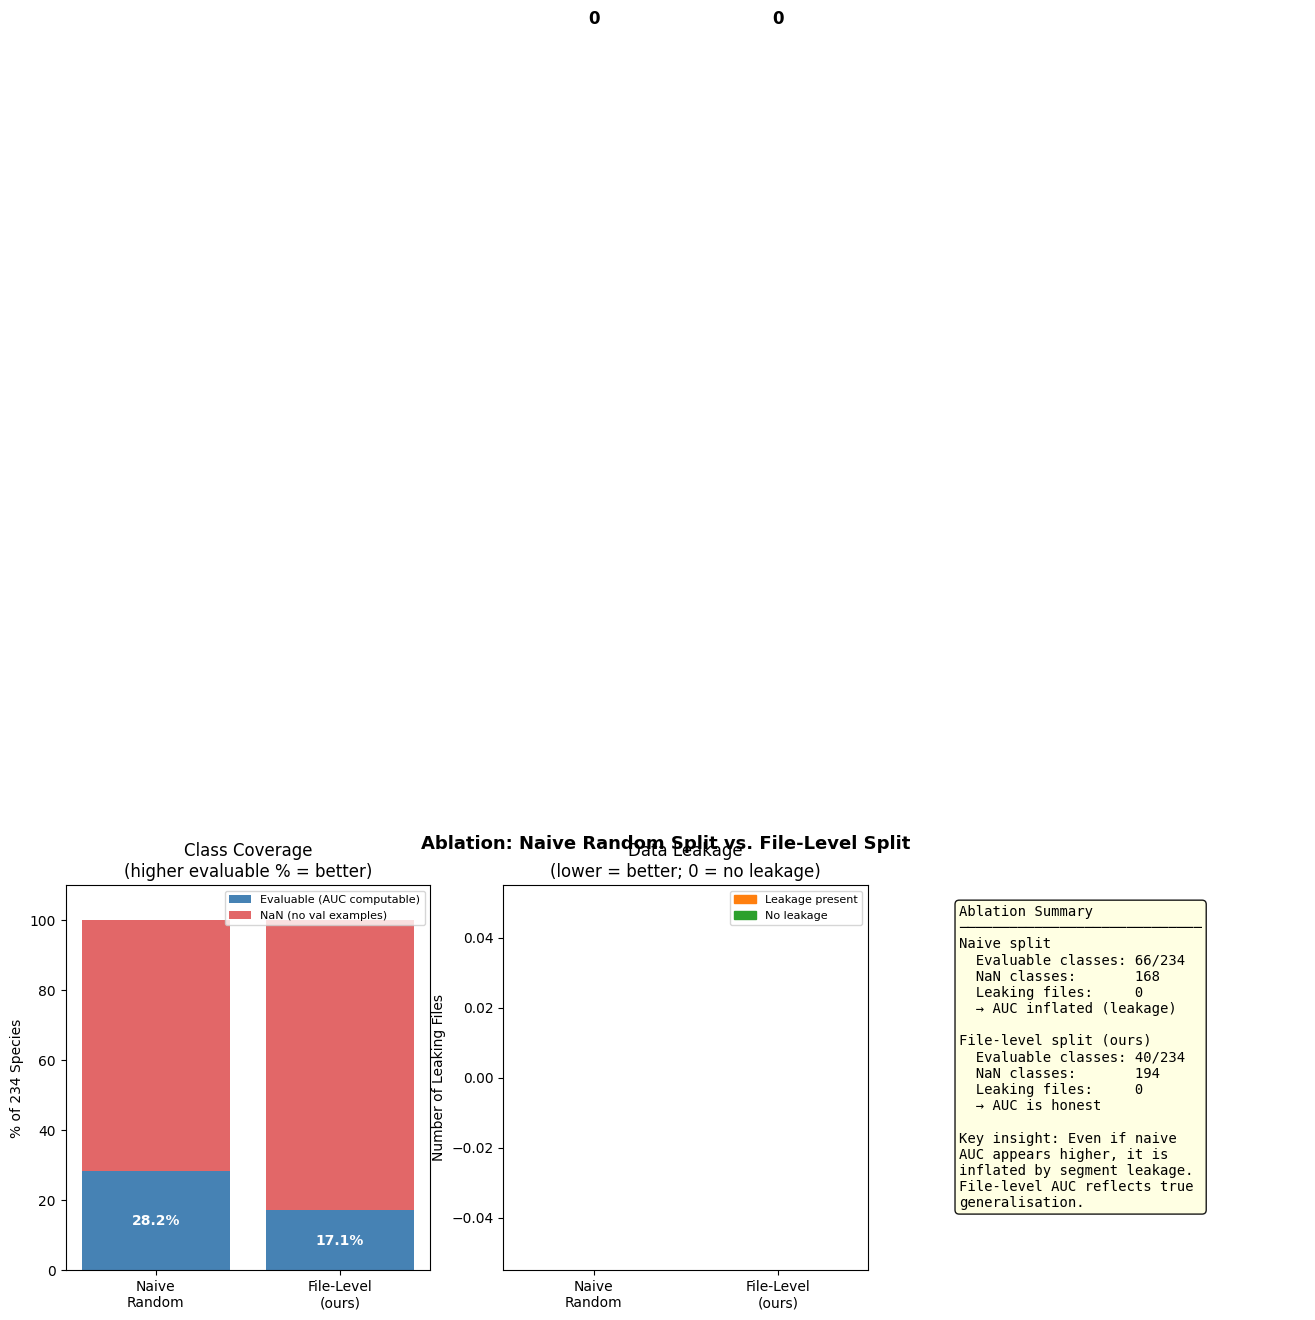

Saved: ablation_split_comparison.png


In [26]:
# ══════════════════════════════════════════════════════════════════
# ABLATION: Naive random split vs. File-level split
# ══════════════════════════════════════════════════════════════════
# This cell runs ENTIRELY on metadata (no model inference needed),
# so it executes quickly. It simulates what AUC coverage looks like
# under each splitting strategy by checking label presence in val.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

SEED = 42

# ── A. Naive random split (segment-level) ────────────────────────
ss_naive_train, ss_naive_val = train_test_split(
    ss_df, test_size=0.2, random_state=SEED
)

# ── B. File-level split (our chosen approach) ────────────────────
# (Already computed above, but recompute here for clarity)
unique_files = ss_df["filename"].unique()
file_train, file_val_files = train_test_split(unique_files, test_size=0.2, random_state=SEED)
ss_file_val = ss_df[ss_df["filename"].isin(file_val_files)]

def coverage_stats(val_df, all_labels, split_name):
    """For each label, check if it appears in the val set. Returns summary dict."""
    val_labels_present = set()
    for cell in val_df["primary_label"].dropna():
        for sp in str(cell).split(";"):
            val_labels_present.add(sp.strip())

    evaluable = sum(1 for lbl in all_labels if lbl in val_labels_present)
    nan_count = len(all_labels) - evaluable

    # Estimate leakage: segments in val whose parent file also appears in train
    val_files = set(val_df["filename"])
    train_df = ss_df[~ss_df["filename"].isin(val_files)]
    train_files = set(train_df["filename"])
    leaked = val_files & train_files  # files that appear in both

    print(f"\n{'─'*50}")
    print(f"  Split: {split_name}")
    print(f"  Val segments: {len(val_df)}")
    print(f"  Evaluable species (AUC computable): {evaluable}/{len(all_labels)} "
          f"({evaluable/len(all_labels)*100:.1f}%)")
    print(f"  NaN species (no val example):       {nan_count} "
          f"({nan_count/len(all_labels)*100:.1f}%)")
    print(f"  Files in val that also appear in train (leakage): {len(leaked)}")
    return {"split": split_name, "evaluable": evaluable, "nan_count": nan_count,
            "total": len(all_labels), "leaked_files": len(leaked)}

all_labels = list(labels)
stats_naive = coverage_stats(ss_naive_val,  all_labels, "Naive random (segment-level)")
stats_file  = coverage_stats(ss_file_val,   all_labels, "File-level split (our approach)")

# ── Visualisation ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Ablation: Naive Random Split vs. File-Level Split",
             fontsize=13, fontweight="bold")

# Panel 1 — Evaluable vs NaN species
ax = axes[0]
x = [0, 1]
evaluable_pct = [s["evaluable"]/s["total"]*100 for s in [stats_naive, stats_file]]
nan_pct       = [s["nan_count"]/s["total"]*100 for s in [stats_naive, stats_file]]
bars_ev  = ax.bar(x, evaluable_pct, color="steelblue", label="Evaluable (AUC computable)")
bars_nan = ax.bar(x, nan_pct, bottom=evaluable_pct, color="#d62728", alpha=0.7,
                  label="NaN (no val examples)")
ax.set_xticks(x)
ax.set_xticklabels(["Naive\nRandom", "File-Level\n(ours)"], fontsize=10)
ax.set_ylabel("% of 234 Species")
ax.set_ylim(0, 110)
ax.set_title("Class Coverage\n(higher evaluable % = better)")
ax.legend(fontsize=8)
for bar, pct in zip(bars_ev, evaluable_pct):
    ax.text(bar.get_x() + bar.get_width()/2, pct/2, f"{pct:.1f}%",
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")

# Panel 2 — Leakage (files that bleed from train → val)
ax2 = axes[1]
leaked = [stats_naive["leaked_files"], stats_file["leaked_files"]]
colors_leak = ["#ff7f0e" if l > 0 else "#2ca02c" for l in leaked]
bars2 = ax2.bar(x, leaked, color=colors_leak)
ax2.set_xticks(x)
ax2.set_xticklabels(["Naive\nRandom", "File-Level\n(ours)"], fontsize=10)
ax2.set_ylabel("Number of Leaking Files")
ax2.set_title("Data Leakage\n(lower = better; 0 = no leakage)")
for bar, val in zip(bars2, leaked):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(leaked)*0.02 if bar.get_height() > 0 else 0.3,
             str(val), ha="center", va="bottom", fontsize=12, fontweight="bold")
ax2.legend(handles=[
    mpatches.Patch(color="#ff7f0e", label="Leakage present"),
    mpatches.Patch(color="#2ca02c", label="No leakage")
], fontsize=8)

# Panel 3 — Expected AUC impact summary text
ax3 = axes[2]
ax3.axis("off")
summary_text = (
    "Ablation Summary\n"
    "─────────────────────────────\n"
    f"Naive split\n"
    f"  Evaluable classes: {stats_naive['evaluable']}/{stats_naive['total']}\n"
    f"  NaN classes:       {stats_naive['nan_count']}\n"
    f"  Leaking files:     {stats_naive['leaked_files']}\n"
    f"  → AUC inflated (leakage)\n\n"
    f"File-level split (ours)\n"
    f"  Evaluable classes: {stats_file['evaluable']}/{stats_file['total']}\n"
    f"  NaN classes:       {stats_file['nan_count']}\n"
    f"  Leaking files:     {stats_file['leaked_files']}\n"
    f"  → AUC is honest\n\n"
    "Key insight: Even if naive\n"
    "AUC appears higher, it is\n"
    "inflated by segment leakage.\n"
    "File-level AUC reflects true\n"
    "generalisation."
)
ax3.text(0.05, 0.95, summary_text, transform=ax3.transAxes, va="top",
         fontsize=10, fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()
plt.savefig("ablation_split_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ablation_split_comparison.png")


Rare-Species Oversampling — Improving Class Coverage
Because rare species appear so infrequently in the train set, the model rarely sees them during an epoch. We apply oversampling using a WeightedRandomSampler so that each species has a more equal chance of being drawn in each batch. This directly addresses the NaN AUC problem by giving the model more exposure to underrepresented calls.

In [27]:
# ══════════════════════════════════════════════════════════════════
# RARE-SPECIES OVERSAMPLING using WeightedRandomSampler
# ══════════════════════════════════════════════════════════════════
from torch.utils.data import WeightedRandomSampler
import numpy as np

def make_weighted_sampler(df, label_col="primary_label"):
    """
    Returns a WeightedRandomSampler that up-weights rare species.
    Each sample's weight = 1 / (count of its species in the dataset).
    This gives rare species the same expected number of appearances
    per epoch as common ones.
    """
    counts = df[label_col].value_counts().to_dict()
    weights = np.array([1.0 / counts.get(row[label_col], 1)
                        for _, row in df.iterrows()], dtype=np.float32)
    weights = weights / weights.sum()  # normalise
    sampler = WeightedRandomSampler(
        weights=weights,
        num_samples=len(df),
        replacement=True  # allows oversampling
    )
    return sampler

# Apply to bird clip training set
bird_sampler = make_weighted_sampler(bird_train_df, label_col="primary_label")

# Rebuild DataLoader with sampler (mutually exclusive with shuffle=True)
bird_train_loader_balanced = DataLoader(
    bird_train_ds,
    batch_size=16,
    sampler=bird_sampler,          # replaces shuffle=True
    num_workers=1,
    pin_memory=True,
    drop_last=True
)

# ── Quick sanity check: species distribution in one epoch ────────
species_counts_before = bird_train_df["primary_label"].value_counts()
print("Before oversampling — species count stats:")
print(f"  Min: {species_counts_before.min()}  Max: {species_counts_before.max()}  "
      f"Mean: {species_counts_before.mean():.1f}  "
      f"Species with 1 sample: {(species_counts_before == 1).sum()}")

# Simulate one epoch of the sampler
simulated_indices = list(iter(bird_sampler))
sampled_species = bird_train_df.iloc[simulated_indices]["primary_label"].value_counts()
print("\nAfter oversampling (simulated epoch) — species count stats:")
print(f"  Min: {sampled_species.min()}  Max: {sampled_species.max()}  "
      f"Mean: {sampled_species.mean():.1f}  "
      f"Species with ≥1 sample: {(sampled_species >= 1).sum()}")
print(f"\n  → Oversampling reduces max/min ratio from "
      f"{species_counts_before.max()/max(species_counts_before.min(),1):.0f}x "
      f"to {sampled_species.max()/max(sampled_species.min(),1):.0f}x")


Before oversampling — species count stats:
  Min: 1  Max: 399  Mean: 127.3  Species with 1 sample: 3

After oversampling (simulated epoch) — species count stats:
  Min: 104  Max: 159  Mean: 127.3  Species with ≥1 sample: 80

  → Oversampling reduces max/min ratio from 399x to 2x
